# CNN From Scratch (PyTorch) - CIFAR-10 Classification

**Dataset:** CIFAR-10 (10 classes, 60,000 images - 50K train / 10K test)

**Classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Architecture:** Custom CNN built from scratch (no pretrained weights)

> Kaggle ပေါ်မှာ GPU accelerator ဖွင့်ပြီး run ပါ: `Settings → Accelerator → GPU`

In [1]:
# --- 1. Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
# --- 2. Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# --- 3. Hyperparameters ---
IMG_SIZE = 32          # CIFAR-10 native size
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
NUM_WORKERS = 2

## Data Loading & Augmentation

CIFAR-10 dataset ကို `torchvision.datasets` ကနေ download ဆွဲပြီး load လုပ်ပါမယ်။

- **Train set:** Data augmentation (RandomCrop, RandomHorizontalFlip) သုံးပါမယ်
- **Validation/Test set:** Augmentation မသုံးပါ (evaluation စစ်ဖို့သာ)

In [6]:
# --- 4. Data Transforms ---
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 mean & std
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [7]:
# --- 5. Download & Load CIFAR-10 ---
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split train into train + validation (45K / 5K)
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {class_names}")

100%|██████████| 170M/170M [00:01<00:00, 86.5MB/s] 


Train: 45000 | Validation: 5000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


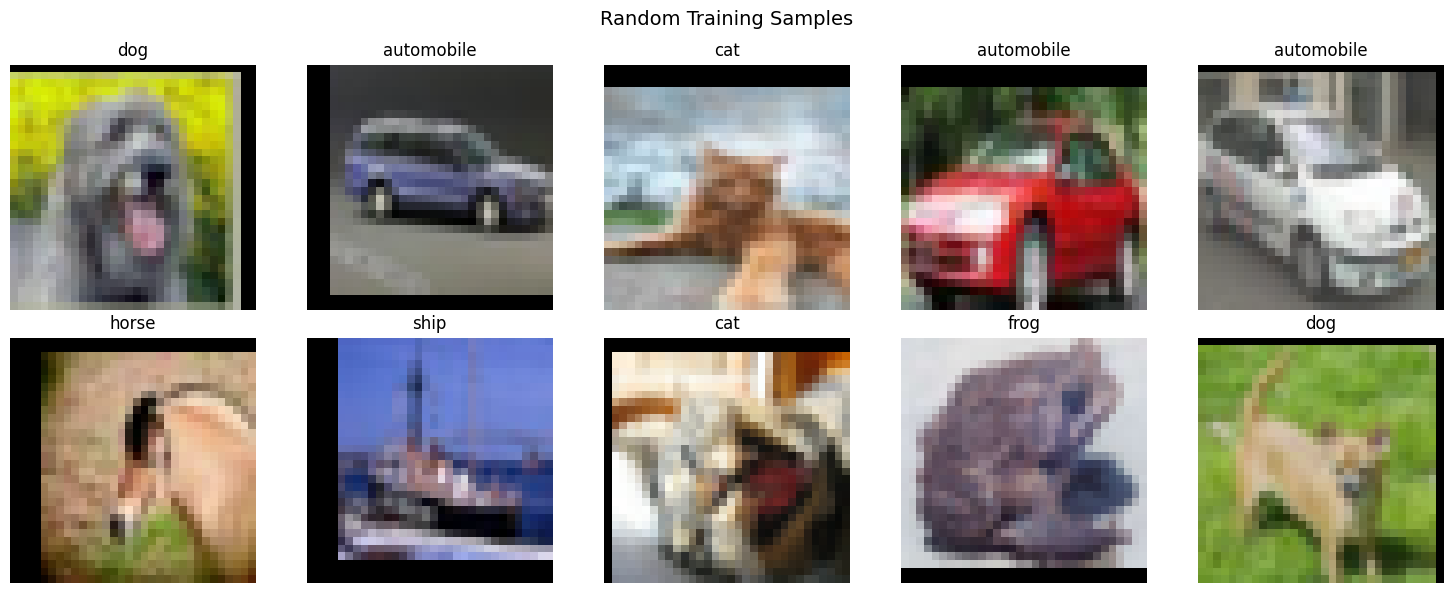

In [8]:
# --- 6. Visualize Sample Images ---
def imshow(img, title=None):
    """Unnormalize and display image"""
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Show 10 random training images
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = random.randint(0, len(full_train_dataset) - 1)
    img, label = full_train_dataset[idx]
    plt.subplot(2, 5, i + 1)
    imshow(img, title=class_names[label])
plt.suptitle("Random Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

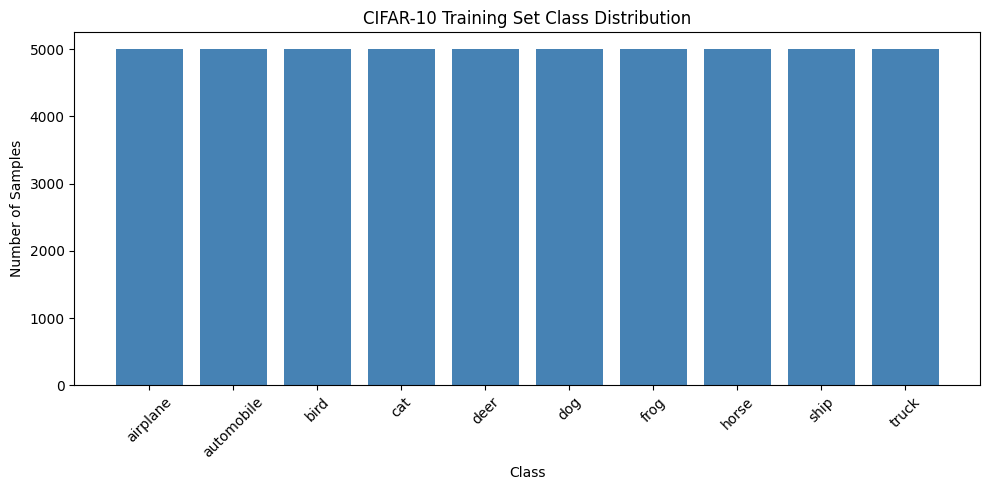

In [9]:
# --- 7. Class Distribution ---
train_labels = [full_train_dataset.targets[i] for i in range(len(full_train_dataset))]
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color='steelblue')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("CIFAR-10 Training Set Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## CNN Model Architecture (From Scratch)

```
Input (3x32x32)
    ↓
Conv2d(3→32, 3x3) → BatchNorm → ReLU → Conv2d(32→32, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓  [32x16x16]
Conv2d(32→64, 3x3) → BatchNorm → ReLU → Conv2d(64→64, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓  [64x8x8]
Conv2d(64→128, 3x3) → BatchNorm → ReLU → Conv2d(128→128, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓  [128x4x4]
Flatten → FC(2048→512) → BatchNorm → ReLU → Dropout(0.5) → FC(512→10)
```

$$Parameters = (Kernel\_Width \times Kernel\_Height \times Input\_Channels \times Output\_Channels) + Output\_Channels \text{ (Bias)}$$

In [10]:
# --- 8. CNN Model Definition ---
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # Block 1: 3 → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(), 
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),  # 10,272 # f(x) = max(0,x)
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25) # output x 0 = 0
        )

        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)   # (B, 32, 16, 16)
        x = self.block2(x)   # (B, 64, 8, 8)
        x = self.block3(x)   # (B, 128, 4, 4)
        x = self.classifier(x)
        return x

model = CNN(num_classes=10).to(device)
print(model)

# Total parameters count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropo

In [18]:
# --- 9. Loss Function & Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [19]:
# --- 10. Training & Validation Functions ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

## Training Loop

Model ကို train လုပ်ပြီး epoch တိုင်းမှာ:
- Training Loss & Accuracy
- Validation Loss & Accuracy
- Learning Rate scheduling (val_loss မကျရင် LR ကိုလျှော့ပေးမယ်)
- Best model ကို save လုပ်မယ်

In [20]:
# --- 11. Training Loop ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_cnn_cifar10.pth")
        print(f"  → Best model saved! (Val Acc: {val_acc:.4f})")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/50] Train Loss: 1.6915 | Train Acc: 0.3791 | Val Loss: 1.2776 | Val Acc: 0.5340
  → Best model saved! (Val Acc: 0.5340)
Epoch [2/50] Train Loss: 1.3360 | Train Acc: 0.5167 | Val Loss: 1.0453 | Val Acc: 0.6228
  → Best model saved! (Val Acc: 0.6228)
Epoch [3/50] Train Loss: 1.1474 | Train Acc: 0.5939 | Val Loss: 0.9228 | Val Acc: 0.6664
  → Best model saved! (Val Acc: 0.6664)
Epoch [4/50] Train Loss: 1.0425 | Train Acc: 0.6327 | Val Loss: 0.7986 | Val Acc: 0.7096
  → Best model saved! (Val Acc: 0.7096)
Epoch [5/50] Train Loss: 0.9653 | Train Acc: 0.6621 | Val Loss: 0.7718 | Val Acc: 0.7202
  → Best model saved! (Val Acc: 0.7202)
Epoch [6/50] Train Loss: 0.9136 | Train Acc: 0.6788 | Val Loss: 0.7125 | Val Acc: 0.7466
  → Best model saved! (Val Acc: 0.7466)
Epoch [7/50] Train Loss: 0.8690 | Train Acc: 0.6957 | Val Loss: 0.6676 | Val Acc: 0.7572
  → Best model saved! (Val Acc: 0.7572)
Epoch [8/50] Train Loss: 0.8229 | Train Acc: 0.7146 | Val Loss: 0.6608 | Val Acc: 0.7648
  → Best

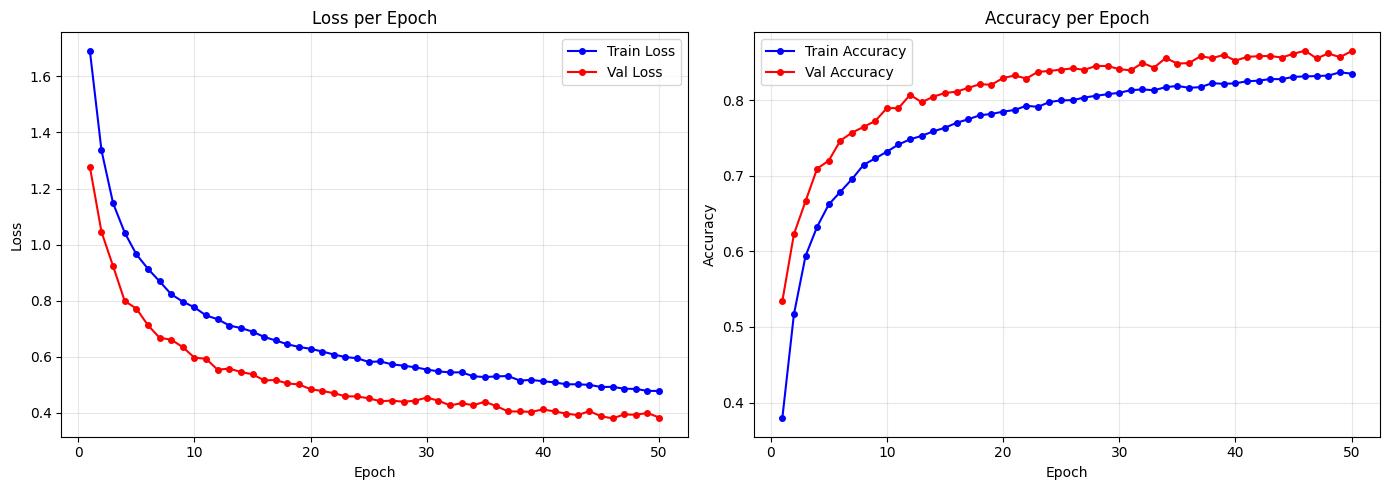

In [24]:
# --- 12. Plot Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='Val Loss', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss per Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, 'r-o', label='Val Accuracy', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy per Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Testing & Evaluation

Best model ကို load ပြန်လုပ်ပြီး Test set ပေါ်မှာ evaluate လုပ်ပါမယ်

In [25]:
# --- 13. Load Best Model & Test ---
model.load_state_dict(torch.load("best_cnn_cifar10.pth", weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.8704

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.87      0.88      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.89      0.78      0.83      1000
         cat       0.79      0.69      0.73      1000
        deer       0.84      0.89      0.87      1000
         dog       0.80      0.81      0.80      1000
        frog       0.87      0.93      0.90      1000
       horse       0.88      0.92      0.90      1000
        ship       0.89      0.94      0.91      1000
       truck       0.91      0.94      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



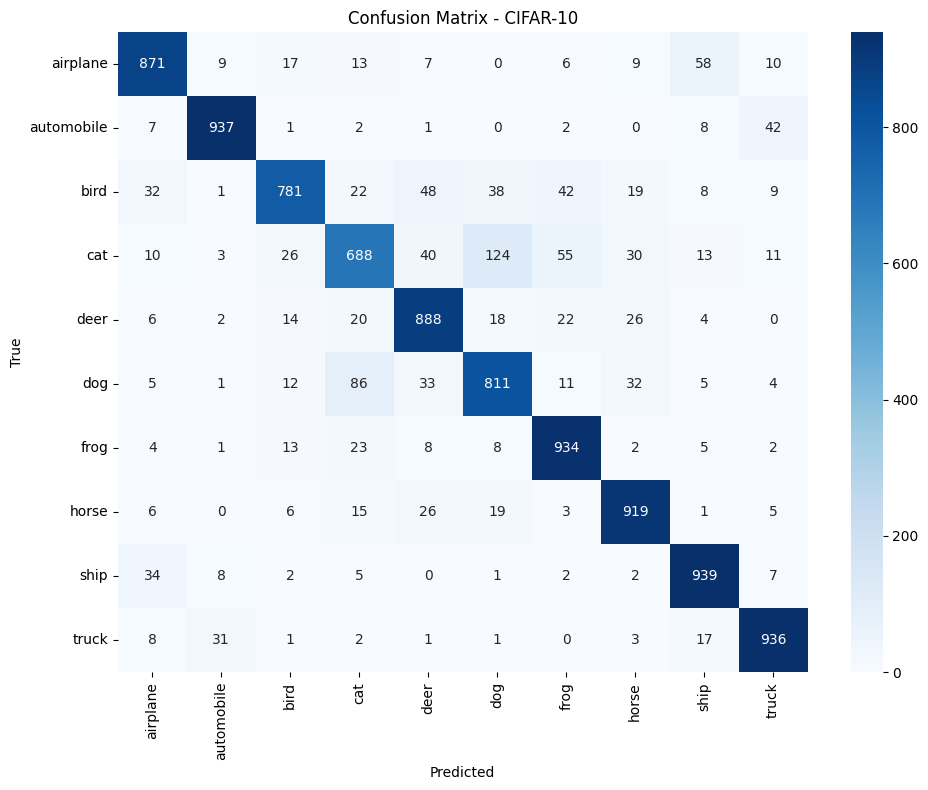

In [26]:
# --- 14. Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CIFAR-10')
plt.tight_layout()
plt.show()

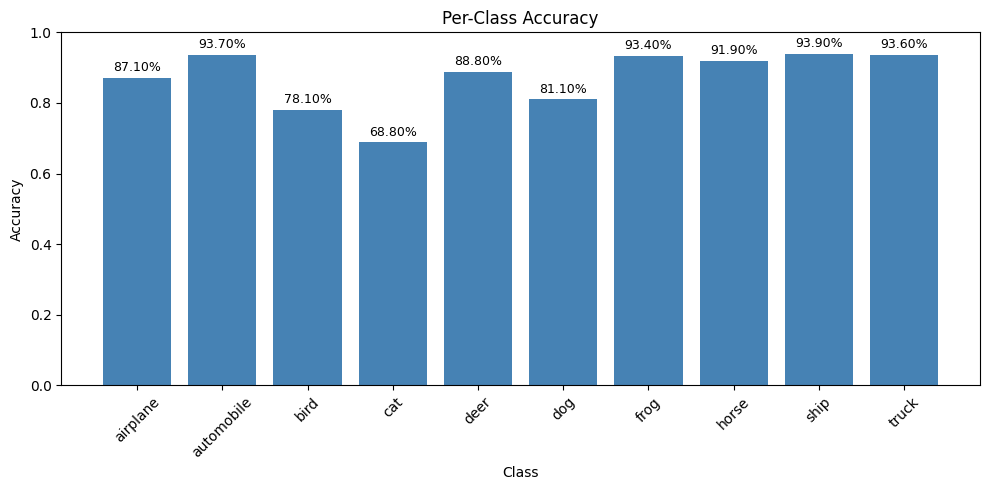

In [28]:
# --- 15. Per-Class Accuracy ---
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
per_class_acc = cm_normalized.diagonal()

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, per_class_acc, color='steelblue')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

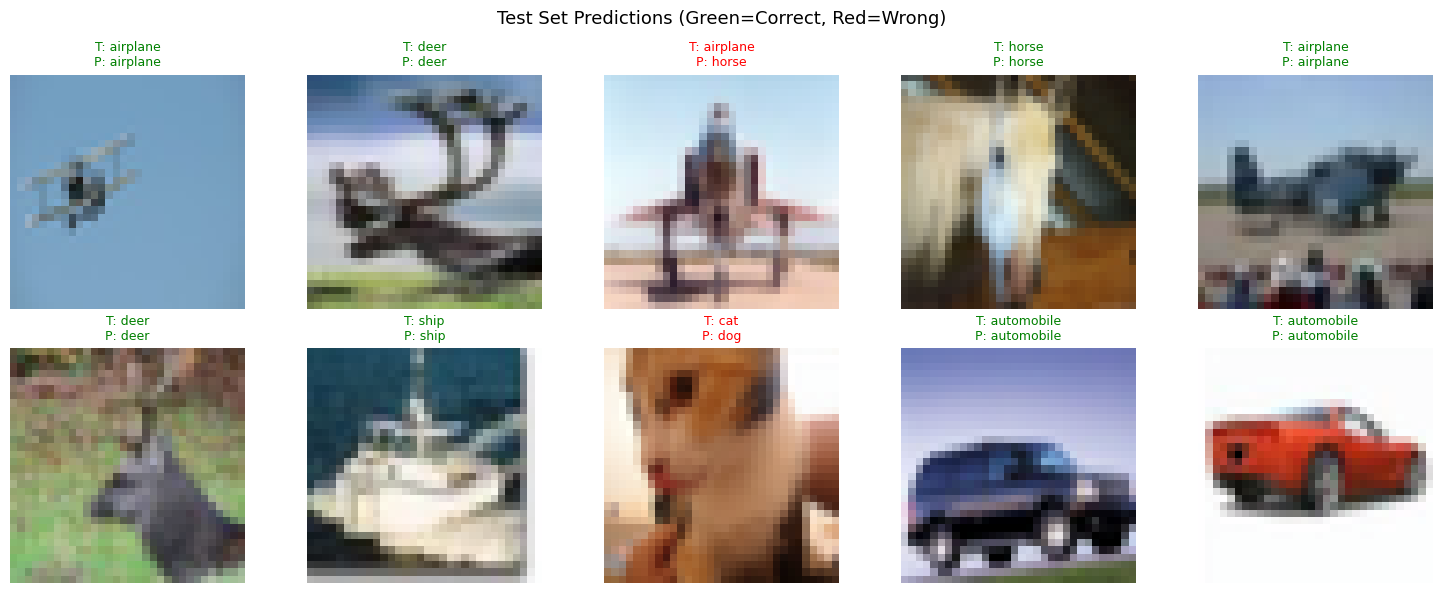

In [29]:
# --- 16. Show Random Predictions from Test Set ---
def show_predictions(model, dataset, class_names, num_images=10):
    model.eval()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    
    plt.figure(figsize=(15, 6))
    indices = random.sample(range(len(dataset)), num_images)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            output = model(img.unsqueeze(0).to(device))
            _, pred = torch.max(output, 1)
            
            # Unnormalize for display
            img_np = img.numpy().transpose((1, 2, 0))
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)
            
            true_label = class_names[label]
            pred_label = class_names[pred.item()]
            color = 'green' if true_label == pred_label else 'red'
            
            plt.subplot(2, 5, i + 1)
            plt.imshow(img_np)
            plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=9)
            plt.axis('off')
    
    plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, class_names, num_images=10)

## Prediction: Logits → Softmax → Class

Model ရဲ့ output (logits) ဟာ raw score တွေဖြစ်ပါတယ်။ ဒါတွေကို `softmax` function နဲ့ probability distribution အဖြစ်ပြောင်းပြီး၊ probability အကြီးဆုံး class ကို predicted class အဖြစ်ယူပါတယ်။

```
Logits (raw scores)  →  Softmax (probabilities)  →  argmax (predicted class)
[-1.2, 3.5, 0.8, ...]  →  [0.02, 0.71, 0.05, ...]  →  class index 1
```

**Softmax Formula:**

$$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

- $z_i$ = logit value for class $i$
- $K$ = total number of classes (10)
- Output: probability distribution (sum = 1.0)

In [ ]:
# --- 17. Prediction: Logits → Softmax → Predicted Class ---
model.eval()
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])

# Random image တစ်ပုံယူမယ်
idx = random.randint(0, len(test_dataset) - 1)
img, true_label = test_dataset[idx]

with torch.no_grad():
    # Model output = logits (raw scores, softmax မသုံးရသေး)
    logits = model(img.unsqueeze(0).to(device))  # shape: (1, 10)

    # Softmax: logits → probabilities (sum = 1.0)
    probabilities = torch.softmax(logits, dim=1)  # shape: (1, 10)

    # argmax: probability အကြီးဆုံး class ကိုယူ
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted_class].item()

# --- Display Results ---
print("=" * 60)
print(f"True Label     : {class_names[true_label]}")
print(f"Predicted Class: {class_names[predicted_class]} (confidence: {confidence:.4f})")
print("=" * 60)

print(f"\nLogits (raw scores from model):")
for i, (name, logit) in enumerate(zip(class_names, logits[0].cpu().numpy())):
    marker = " <--" if i == predicted_class else ""
    print(f"  {name:>12s}: {logit:>8.4f}{marker}")

print(f"\nSoftmax Probabilities:")
for i, (name, prob) in enumerate(zip(class_names, probabilities[0].cpu().numpy())):
    bar = "█" * int(prob * 40)
    marker = " <-- predicted" if i == predicted_class else ""
    print(f"  {name:>12s}: {prob:.4f} {bar}{marker}")

print(f"\n  Sum of probabilities: {probabilities[0].sum().item():.4f}")

In [ ]:
# --- 18. Visualize: Image + Logits + Softmax Probabilities ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [1, 1.5, 1.5]})

# (1) Image ပြ
img_np = img.numpy().transpose((1, 2, 0))
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)
axes[0].imshow(img_np)
color = 'green' if true_label == predicted_class else 'red'
axes[0].set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_class]}", 
                  color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

# (2) Logits bar chart
logit_values = logits[0].cpu().numpy()
colors_logit = ['orangered' if i == predicted_class else 'steelblue' for i in range(len(class_names))]
axes[1].barh(class_names, logit_values, color=colors_logit)
axes[1].set_xlabel('Logit Value (Raw Score)')
axes[1].set_title('Logits (Model Output)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(logit_values):
    axes[1].text(v + 0.1 if v >= 0 else v - 0.1, i, f'{v:.2f}', 
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# (3) Softmax probabilities bar chart
prob_values = probabilities[0].cpu().numpy()
colors_prob = ['orangered' if i == predicted_class else 'steelblue' for i in range(len(class_names))]
axes[2].barh(class_names, prob_values, color=colors_prob)
axes[2].set_xlabel('Probability')
axes[2].set_title('Softmax Probabilities', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 1)
axes[2].invert_yaxis()
for i, v in enumerate(prob_values):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle("Logits → Softmax → Prediction", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()